#### Binary Classification — Pre vs Post War (Individual)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from functools import reduce
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')


In [3]:
war_date = pd.to_datetime('2022-02-24')
pre_start = war_date - pd.DateOffset(months=6)
post_end = war_date + pd.DateOffset(months=6)

In [4]:
exclude = [
    '06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f',
    '179bbc95-ec8b-4a65-98c5-5d3b566806fa'
]

In [5]:
min_days_per_period = 30

cv_folds = 10
threshold = 0.8

In [6]:
base = daily_data

msg_df = pd.read_csv(base / 'donor_daily_message_count.csv')
chats_df = pd.read_csv(base / 'daily_active_chats.csv')
audio_df = pd.read_csv(base / 'donor_daily_audio.csv')
posts_df = pd.read_csv(base / 'donor_daily_posts.csv')
shares_df = pd.read_csv(base / 'donor_daily_time_shares.csv')
length_df = pd.read_csv(base / 'donor_daily_avg_length.csv')
comments_df = pd.read_csv(base / 'donor_daily_comments.csv')
react_df = pd.read_csv(base / 'donor_daily_reactions.csv')
hours_df = pd.read_csv(base / 'donor_daily_active_hours.csv')
received_df = pd.read_csv(base / 'donor_daily_messages_received.csv')
words_rec_df= pd.read_csv(base / 'donor_daily_words_received.csv')
word_cnt_df = pd.read_csv(base / 'donor_daily_word_count.csv')
night_react_df = pd.read_csv(base / 'donor_daily_night_share_reactions.csv')
frac_top5_df = pd.read_csv(base / 'donor_daily_frac_words_top5.csv')

for d in [msg_df, chats_df, audio_df, posts_df, shares_df, length_df,
          comments_df, react_df, hours_df, received_df, words_rec_df,
          word_cnt_df, night_react_df, frac_top5_df]:
    d['date'] = pd.to_datetime(d['date'])


In [7]:
dfs = [msg_df, chats_df, audio_df, posts_df, shares_df, length_df,
       comments_df, react_df, hours_df, received_df, words_rec_df,
       word_cnt_df, night_react_df, frac_top5_df]

df = reduce(lambda l, r: pd.merge(l, r, on=['donation_id', 'date'], how='outer'), dfs)
df = df.fillna(0)

df['words_sent_over_words_received'] = (df['donor_daily_word_count'] / (df['words_received'] + 1e-9))

df = df[~df['donation_id'].isin(exclude)]

df = df[(df['date'] >= pre_start) & (df['date'] <= post_end)]

df['label'] = (df['date'] >= war_date).astype(int)

print(f'Donors: {df["donation_id"].nunique()}')
print(f'Rows: {len(df):,}')
print(f'Before: {(df["label"]==0).sum():,} days')
print(f'After: {(df["label"]==1).sum():,} days')


Donors: 22
Rows: 7,512
Before: 3,696 days
After: 3,816 days


#### Features

In [8]:
features = [
    # activity sent
    'donor_daily_message_count',
    'donor_daily_avg_length',
    'donor_daily_audio_count',
    'daily_active_chats',
    'donor_daily_active_hours',
    # activity received
    'n_messages_received',
    # ratio
    'words_sent_over_words_received',
    # public activity 
    'donor_daily_post_count',
    'donor_daily_comment_count',
    'donor_daily_reaction_count',
    # temporal patterns
    'night_share',
    'night_share_reactions',
    # social structure
    'frac_words_closest_5_contacts',
]

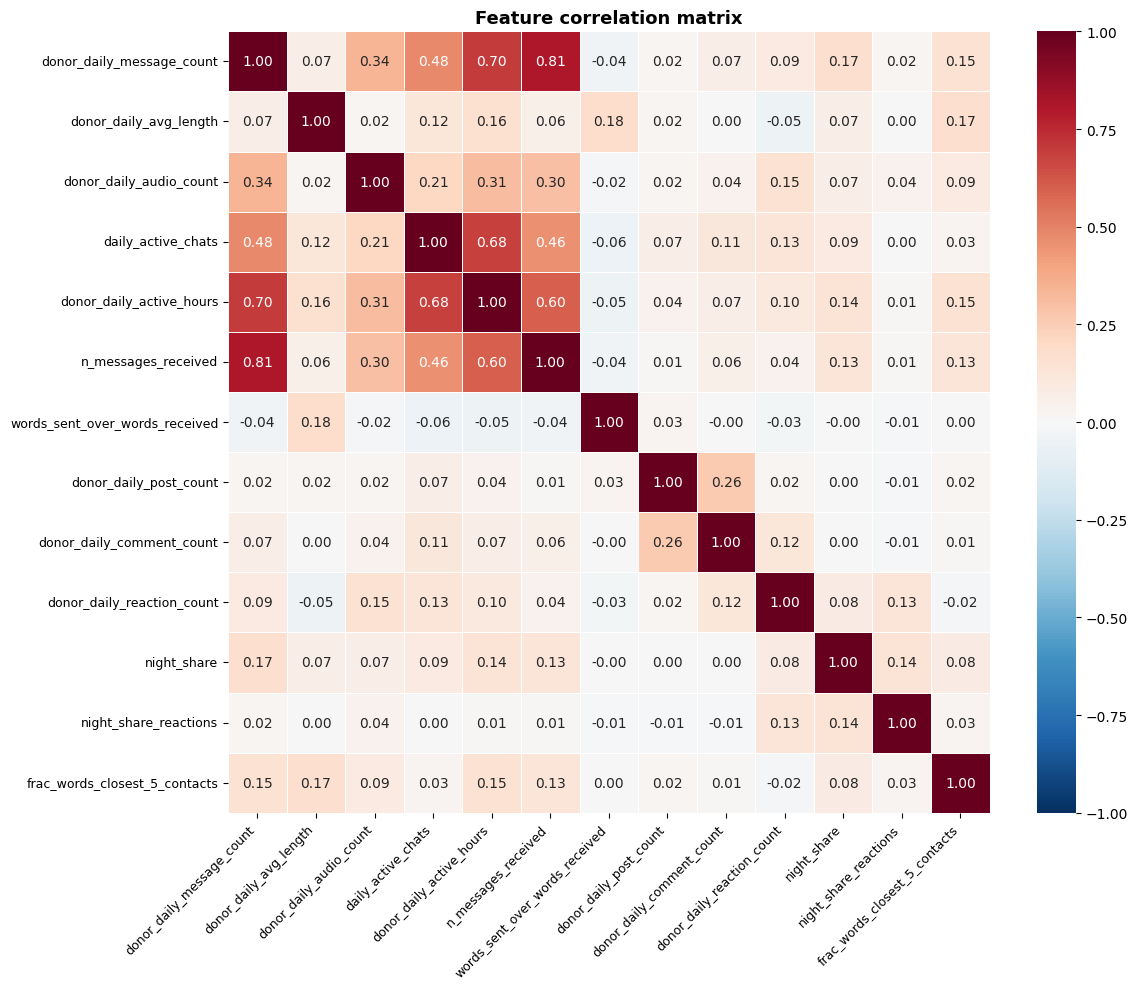

In [9]:
corr = df[features].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('Feature correlation matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

#### Models

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

For each donor separately, four models are evaluated using StratifiedKFold.

Features are standardized within each fold using StandardScaler: the mean and standard deviation are computed on the training portion only and then applied to the test fold.

In [11]:
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
results = []
importances = []

all_donors = df['donation_id'].unique()

for donor_id in all_donors:
    d = df[df['donation_id'] == donor_id].copy()

    n_pre = (d['label'] == 0).sum()
    n_post = (d['label'] == 1).sum()
    if n_pre < min_days_per_period or n_post < min_days_per_period:
        print(f'Skip {donor_id[:8]}: pre={n_pre}, post={n_post}')
        continue


    d = d.sample(frac=1, random_state=42).reset_index(drop=True)

    X = d[features].values
    y = d['label'].values

    for model_name, model in models.items():

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
        cv_scores_f1 = cross_val_score(pipe, X, y, cv=cv, scoring='f1') 

        results.append({
            'donor_id': donor_id,
            'donor_short': donor_id[:8],
            'model': model_name,
            'cv_mean': round(cv_scores.mean(), 4),
            'cv_std': round(cv_scores.std(), 4),
            'cv_mean_f1': round(cv_scores_f1.mean(), 4),  
            'cv_std_f1': round(cv_scores_f1.std(), 4),   
            'n_pre': n_pre,
            'n_post': n_post,
        })

        pipe.fit(X, y)
        fitted_model = pipe.named_steps['model']

        if hasattr(fitted_model, 'coef_'):
            imp = np.abs(fitted_model.coef_[0])
        elif hasattr(fitted_model, 'feature_importances_'):
            imp = fitted_model.feature_importances_
        else:
            imp = np.zeros(len(features))

        for feat, val in zip(features, imp):
            importances.append({
                'donor_id': donor_id,
                'model': model_name,
                'feature': feat,
                'importance': val,
            })

results_df = pd.DataFrame(results)
importances_df = pd.DataFrame(importances)

print(f'Donors: {results_df["donor_id"].nunique()}')
print(f'Rows: {len(results_df)}')


Donors: 22
Rows: 88


In [12]:
summary = results_df.groupby('model')[['cv_mean', 'cv_mean_f1']].agg(['mean', 'std']).round(3)
display(summary)

cv_mean        cv_mean_f1       
                       mean    std       mean    std
model                                               
Gradient Boosting     0.702  0.105      0.702  0.109
Linear SVM            0.713  0.095      0.716  0.098
Logistic Regression   0.715  0.090      0.718  0.095
Random Forest         0.705  0.115      0.706  0.118

#### Bar plot accuracy per donor 

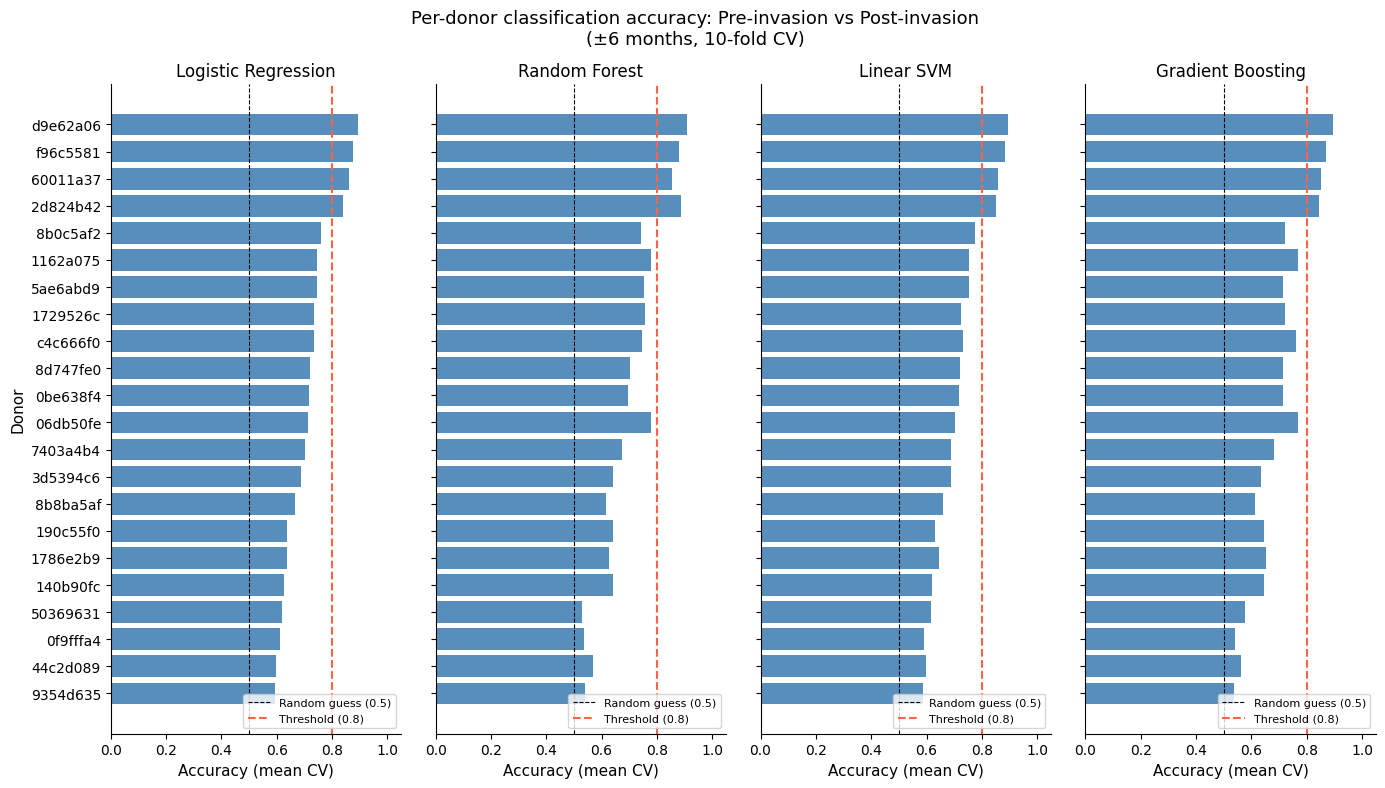

In [13]:
model_names = list(models.keys())
n_models = len(model_names)

fig, axes = plt.subplots(1, n_models, figsize=(3.5 * n_models, 8), sharey=True)

for ax, model_name in zip(axes, model_names):
    df_m = results_df[results_df['model'] == model_name].sort_values('cv_mean')

    ax.barh(df_m['donor_short'], df_m['cv_mean'], color='steelblue', alpha=0.9)
    ax.axvline(0.5, color='black', linewidth=0.8, linestyle='--', label='Random guess (0.5)')

    ax.axvline(threshold, color='tomato', linewidth=1.5, linestyle='--', label=f'Threshold ({threshold})')

    ax.set_xlabel('Accuracy (mean CV)', fontsize=11)
    ax.set_title(model_name, fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)


axes[0].set_ylabel('Donor', fontsize=11)
plt.suptitle('Per-donor classification accuracy: Pre-invasion vs Post-invasion\n'
             f'(±6 months, {cv_folds}-fold CV)', fontsize=13)
plt.tight_layout()
plt.show()


#### Feature importance

In [14]:
def normalize_importance(group):
    total = group['importance'].sum()
    if total > 0:
        group['importance_norm'] = group['importance'] / total
    else:
        group['importance_norm'] = 0
    return group

imp_norm = (importances_df
    .groupby(['donor_id', 'model'], group_keys=False)
    .apply(normalize_importance))

agg_imp = (imp_norm
    .groupby(['model', 'feature'])['importance_norm']
    .mean()
    .reset_index()
    .sort_values(['model', 'importance_norm'], ascending=[True, False]))


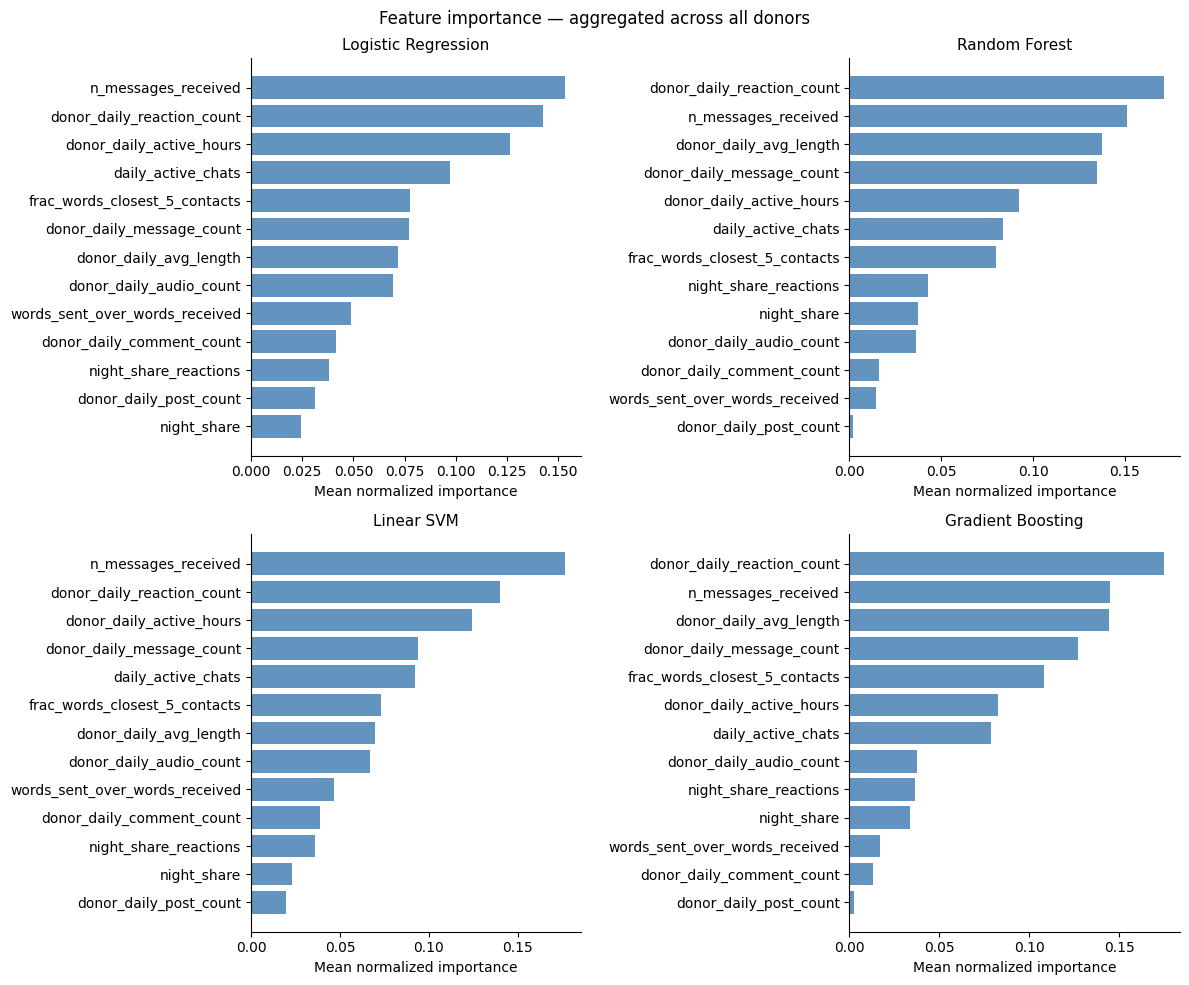

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, model_name in zip(axes, model_names):
    df_i = agg_imp[agg_imp['model'] == model_name].sort_values('importance_norm')

    ax.barh(df_i['feature'], df_i['importance_norm'],
            color='steelblue', alpha=0.85)
    ax.set_xlabel('Mean normalized importance', fontsize=10)
    ax.set_title(model_name, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature importance — aggregated across all donors', fontsize=12)
plt.tight_layout()
plt.show()